In [1]:
import pandas as pd
import numpy as np
file_path = r'C:\Users\Devon\Documents\WGU MSDA\D208\medical_clean.csv'
df = pd.read_csv(file_path, index_col = 0)
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_id         10000 non-null  object 
 1   Interaction         10000 non-null  object 
 2   UID                 10000 non-null  object 
 3   City                10000 non-null  object 
 4   State               10000 non-null  object 
 5   County              10000 non-null  object 
 6   Zip                 10000 non-null  int64  
 7   Lat                 10000 non-null  float64
 8   Lng                 10000 non-null  float64
 9   Population          10000 non-null  int64  
 10  Area                10000 non-null  object 
 11  TimeZone            10000 non-null  object 
 12  Job                 10000 non-null  object 
 13  Children            10000 non-null  int64  
 14  Age                 10000 non-null  int64  
 15  Income              10000 non-null  float64
 16  Marital  

In [2]:
#Finding the number of records and columns in the dataset
df.shape

(10000, 49)

In [3]:
#Looking for duplicates in the dataset
df.duplicated().sum()

0

In [4]:
#Looking for missing values in the dataset
df.isna().sum()
rows_with_null = df.isnull().any(axis=1).sum()
print(rows_with_null)

0


In [5]:
#Looking for discrepancies in state abbreviations
print(df['State'].unique())
df.State.value_counts().count()

['AL' 'FL' 'SD' 'MN' 'VA' 'OK' 'OH' 'MS' 'WI' 'IA' 'CA' 'IN' 'MO' 'MI'
 'NE' 'PA' 'AR' 'WV' 'KS' 'MA' 'KY' 'NY' 'VT' 'DC' 'IL' 'ND' 'SC' 'AK'
 'NM' 'NH' 'GA' 'NC' 'MD' 'TN' 'WA' 'TX' 'CO' 'NJ' 'LA' 'OR' 'AZ' 'ME'
 'ID' 'UT' 'RI' 'MT' 'PR' 'NV' 'CT' 'HI' 'WY' 'DE']


52

In [6]:
#Investigating outliers in the VitD_levels variable
import sklearn

# IQR
# Calculate the upper and lower limits
Q1 = df['VitD_levels'].quantile(0.25)
Q3 = df['VitD_levels'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(IQR)

# Create arrays of Boolean values indicating the outlier rows
upper_array = np.where(df['VitD_levels'] >= upper)[0]
print(len(upper_array))
lower_array = np.where(df['VitD_levels'] <= lower)[0]
print(len(lower_array))

2.721523887500002
33
27


<Axes: ylabel='VitD_levels'>

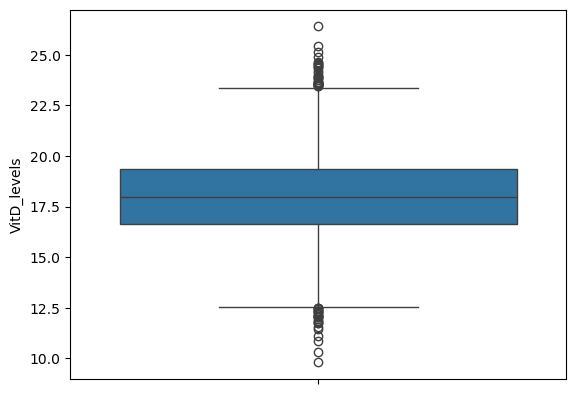

In [7]:
# Box Plot for VitD_levels
import seaborn as sns
sns.boxplot(df['VitD_levels'])

In [8]:
# Looking for highest and lowest 20 values in VitD_levels
print(df.VitD_levels.nlargest(n=20))
print(df.VitD_levels.nsmallest(n=20))

CaseOrder
4370    26.394449
4186    25.444099
6830    25.147270
8252    24.889110
7910    24.637420
23      24.565463
508     24.559132
8851    24.538710
8349    24.450370
4530    24.421656
2383    24.371580
6948    24.356250
8409    24.166720
8844    24.098840
1664    23.941426
3564    23.938421
468     23.906407
2705    23.852194
7158    23.833530
8576    23.739160
Name: VitD_levels, dtype: float64
CaseOrder
8141     9.806483
3289    10.315234
1316    10.877427
5259    11.083430
636     11.475314
5066    11.538730
9271    11.751060
8492    11.755560
510     11.785395
7188    11.846830
6793    11.966340
9510    12.038470
4382    12.062467
1629    12.072534
4260    12.074147
1440    12.091658
8198    12.118830
3503    12.207388
7226    12.219040
813     12.313590
Name: VitD_levels, dtype: float64


In [9]:
#Investigating outliers in the TotalCharge variable
import sklearn

# IQR
# Calculate the upper and lower limits
Q1 = df['TotalCharge'].quantile(0.25)
Q3 = df['TotalCharge'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(IQR)

# Create arrays of Boolean values indicating the outlier rows
upper_array = np.where(df['TotalCharge'] >= upper)[0]
print(len(upper_array))
lower_array = np.where(df['TotalCharge'] <= lower)[0]
print(len(lower_array))

4280.325734999999
0
0


<Axes: ylabel='TotalCharge'>

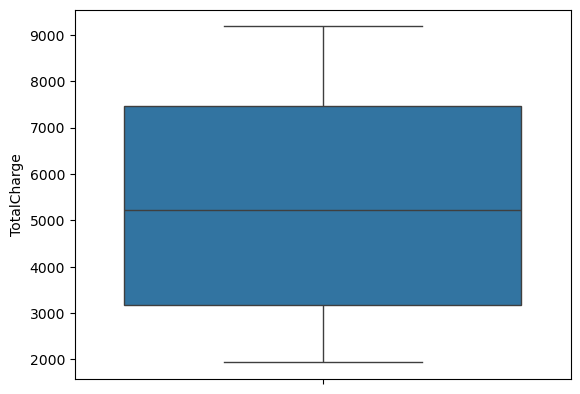

In [10]:
# Box Plot for TotalCharge
import seaborn as sns
sns.boxplot(df['TotalCharge'])

In [11]:
new_columns = ["customer_id", "interaction", "uid", "city", "state", "county", 
                    "zip", "latitude", "longitude", "population", "area", "timezone", "job", "children_in_household", 
                    "age", "sponsor_income", "marital_status", "gender", "readmis_within_month", 
                    "vitd_lvl", "pcm_visits", "hosp_meals_eaten", "vitd_supp", "soft_drink_consumption", "initial_admin", 
                    "high_blood_pressure", "stroke", "complication_risk", "overweight", "arthritis", "diabetes", "hyperlipidemia", 
                    "back_pain", "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma", "services", 
                    "initial_stay", "est_daily_charge", "est_additional_charges", "likert_timely_admission", "likert_timely_treatment", 
                    "likert_timely_visit", "likert_reliablity", "likert_options", "likert_treatment_hrs", "likert_courteous_staff", 
                    "likert_dr_active_listening"]
df.columns = new_columns
print(df.columns)

Index(['customer_id', 'interaction', 'uid', 'city', 'state', 'county', 'zip',
       'latitude', 'longitude', 'population', 'area', 'timezone', 'job',
       'children_in_household', 'age', 'sponsor_income', 'marital_status',
       'gender', 'readmis_within_month', 'vitd_lvl', 'pcm_visits',
       'hosp_meals_eaten', 'vitd_supp', 'soft_drink_consumption',
       'initial_admin', 'high_blood_pressure', 'stroke', 'complication_risk',
       'overweight', 'arthritis', 'diabetes', 'hyperlipidemia', 'back_pain',
       'anxiety', 'allergic_rhinitis', 'reflux_esophagitis', 'asthma',
       'services', 'initial_stay', 'est_daily_charge',
       'est_additional_charges', 'likert_timely_admission',
       'likert_timely_treatment', 'likert_timely_visit', 'likert_reliablity',
       'likert_options', 'likert_treatment_hrs', 'likert_courteous_staff',
       'likert_dr_active_listening'],
      dtype='object')


In [12]:
#Code showing summary statistics for the est_daily_charge variable (continuous/dependent)
print(df.est_daily_charge.describe())
print(df.est_daily_charge.nlargest(n=20))
print(df.est_daily_charge.nsmallest(n=20))

count    10000.000000
mean      5312.172769
std       2180.393838
min       1938.312067
25%       3179.374015
50%       5213.952000
75%       7459.699750
max       9180.728000
Name: est_daily_charge, dtype: float64
CaseOrder
5713    9180.728
8988    9169.248
5501    9080.912
9404    9077.388
5462    9067.605
7711    9065.054
9136    9028.118
7826    9022.166
9158    9012.388
7295    9004.401
7147    8990.888
9257    8979.087
7215    8975.566
7044    8969.073
9583    8963.124
6690    8962.874
5649    8957.794
7613    8950.139
5066    8948.540
8916    8943.753
Name: est_daily_charge, dtype: float64
CaseOrder
2509    1938.312067
3655    1957.445547
2496    1969.472468
4213    2000.776336
3086    2004.755279
4641    2006.878935
4427    2010.399554
335     2022.650007
2952    2027.222670
2500    2035.787412
3379    2037.805570
227     2041.113490
2826    2041.252401
2781    2061.043367
286     2070.180736
2918    2070.504072
947     2073.147199
1124    2074.719538
1135    2077.435112
1748  

In [13]:
#Code showing summary statistics  variable and conducting t-test of independence exploring the potential relationship between patients' vitamin d levels (continuous/independent variable) and total charge (continuous/dependent variable)
import pandas as pd
import scipy.stats as stats
from scipy.stats import pearsonr

print(df.vitd_lvl.describe())
print(df.vitd_lvl.nlargest(n=20))
print(df.vitd_lvl.nsmallest(n=20))
pearson_r_test = stats.pearsonr(df.est_daily_charge, df.vitd_lvl)
print(pearson_r_test)

count    10000.000000
mean        17.964262
std          2.017231
min          9.806483
25%         16.626439
50%         17.951122
75%         19.347963
max         26.394449
Name: vitd_lvl, dtype: float64
CaseOrder
4370    26.394449
4186    25.444099
6830    25.147270
8252    24.889110
7910    24.637420
23      24.565463
508     24.559132
8851    24.538710
8349    24.450370
4530    24.421656
2383    24.371580
6948    24.356250
8409    24.166720
8844    24.098840
1664    23.941426
3564    23.938421
468     23.906407
2705    23.852194
7158    23.833530
8576    23.739160
Name: vitd_lvl, dtype: float64
CaseOrder
8141     9.806483
3289    10.315234
1316    10.877427
5259    11.083430
636     11.475314
5066    11.538730
9271    11.751060
8492    11.755560
510     11.785395
7188    11.846830
6793    11.966340
9510    12.038470
4382    12.062467
1629    12.072534
4260    12.074147
1440    12.091658
8198    12.118830
3503    12.207388
7226    12.219040
813     12.313590
Name: vitd_lvl, dtype:

In [14]:
#Code showing summary statistics the high blood pressure variable and conducting t-test of independence exploring the potential relationship between stroke patients (categorical/independent variable) and estimated daily charge (independent/continuous variable)
print(df.high_blood_pressure.value_counts())

stats.ttest_ind(df['est_daily_charge'][df['high_blood_pressure'] == 'Yes'],
                df['est_daily_charge'][df['high_blood_pressure'] == 'No'])

high_blood_pressure
No     5910
Yes    4090
Name: count, dtype: int64


TtestResult(statistic=1.991173764598315, pvalue=0.046488954966221054, df=9998.0)

In [15]:
#Code showing summary statistics the stroke variable and conducting t-test of independence exploring the potential relationship between stroke patients (categorical/independent variable) and estimated daily charge (independent/continuous variable)
print(df.stroke.value_counts())

stats.ttest_ind(df['est_daily_charge'][df['stroke'] == 'Yes'],
                df['est_daily_charge'][df['stroke'] == 'No'])

stroke
No     8007
Yes    1993
Name: count, dtype: int64


TtestResult(statistic=-0.36935202494959557, pvalue=0.7118731742662484, df=9998.0)

In [16]:
#Code showing summary statistics the complication risk variable and conducting t-test of independence exploring the potential relationship between stroke patients (categorical/independent variable) and estimated daily charge (independent/continuous variable)
print(df.complication_risk.value_counts())

from scipy.stats import f_oneway
high = df['est_daily_charge'][df['complication_risk'] == 'High'].values
medium = df['est_daily_charge'][df['complication_risk'] == 'Medium'].values
low = df['est_daily_charge'][df['complication_risk'] == 'Low'].values
f_oneway(high, medium, low)

complication_risk
Medium    4517
High      3358
Low       2125
Name: count, dtype: int64


F_onewayResult(statistic=37.39117641717796, pvalue=6.632146957801407e-17)

In [17]:
#Code showing summary statistics for the overweight variable and conducting t-test of independence exploring the potential relationship between overweight patients (categorical variable) and estimated daily charge (independent/continuous variable)
print(df.overweight.value_counts())
stats.ttest_ind(df['est_daily_charge'][df['overweight'] == 'Yes'],
                df['est_daily_charge'][df['overweight'] == 'No'])

overweight
Yes    7094
No     2906
Name: count, dtype: int64


TtestResult(statistic=-1.2781957011833045, pvalue=0.2012101044949886, df=9998.0)

In [18]:
#Code showing summary statistics for the arthritis variable and conducting t-test of independence exploring the potential relationship between arthritis patients (categorical variable) and estimated daily charge (independent/continuous variable)
print(df.arthritis.value_counts())
stats.ttest_ind(df['est_daily_charge'][df['arthritis'] == 'Yes'],
                df['est_daily_charge'][df['arthritis'] == 'No'])

arthritis
No     6426
Yes    3574
Name: count, dtype: int64


TtestResult(statistic=3.294673072136911, pvalue=0.000988790301035799, df=9998.0)

In [19]:
#Code showing summary statistics for the diabetes variable and conducting t-test of independence exploring the potential relationship between diabetes patients (categorical variable) and estimated daily charge (independent/continuous variable)
print(df.diabetes.value_counts())
stats.ttest_ind(df['est_daily_charge'][df['diabetes'] == 'Yes'],
                df['est_daily_charge'][df['diabetes'] == 'No'])

diabetes
No     7262
Yes    2738
Name: count, dtype: int64


TtestResult(statistic=1.152407066137314, pvalue=0.24918139185033356, df=9998.0)

In [20]:
#Code showing summary statistics for the hyperlipidemia variable and conducting t-test of independence exploring the potential relationship between hyperlipidemia patients (categorical variable) and estimated daily charge (independent/continuous variable)
print(df.hyperlipidemia.value_counts())
stats.ttest_ind(df['est_daily_charge'][df['hyperlipidemia'] == 'Yes'],
                df['est_daily_charge'][df['hyperlipidemia'] == 'No'])

hyperlipidemia
No     6628
Yes    3372
Name: count, dtype: int64


TtestResult(statistic=1.7566194513396673, pvalue=0.0790133049992354, df=9998.0)

In [21]:
#Code showing summary statistics for the back pain variable and conducting t-test of independence exploring the potential relationship between patients with back pain (categorical variable) and estimated daily charge (independent/continuous variable)
print(df.back_pain.value_counts())
stats.ttest_ind(df['est_daily_charge'][df['back_pain'] == 'Yes'],
                df['est_daily_charge'][df['back_pain'] == 'No'])

back_pain
No     5886
Yes    4114
Name: count, dtype: int64


TtestResult(statistic=3.584703001906038, pvalue=0.0003390696148252136, df=9998.0)

In [22]:
#Code showing summary statistics for the anxiety variable and conducting t-test of independence exploring the potential relationship between patients with anxiety (categorical variable) and estimated daily charge (independent/continuous variable)
print(df.anxiety.value_counts())
stats.ttest_ind(df['est_daily_charge'][df['anxiety'] == 'Yes'],
                df['est_daily_charge'][df['anxiety'] == 'No'])

anxiety
No     6785
Yes    3215
Name: count, dtype: int64


TtestResult(statistic=3.1210811595304135, pvalue=0.0018070170769474245, df=9998.0)

In [23]:
#Code showing summary statistics for the allergic rhinitis variable and conducting t-test of independence exploring the potential relationship between patients with allergic rhinitis (categorical variable) and estimated daily charge (independent/continuous variable)
print(df.allergic_rhinitis.value_counts())
stats.ttest_ind(df['est_daily_charge'][df['allergic_rhinitis'] == 'Yes'],
                df['est_daily_charge'][df['allergic_rhinitis'] == 'No'])

allergic_rhinitis
No     6059
Yes    3941
Name: count, dtype: int64


TtestResult(statistic=1.892088366157646, pvalue=0.05850807484853946, df=9998.0)

In [24]:
#Code showing summary statistics for the reflux esophagitis variable and conducting t-test of independence exploring the potential relationship between patients with reflux esophagitis (categorical variable) and estimated daily charge (independent/continuous variable)
print(df.reflux_esophagitis.value_counts())
stats.ttest_ind(df['est_daily_charge'][df['reflux_esophagitis'] == 'Yes'],
                df['est_daily_charge'][df['reflux_esophagitis'] == 'No'])

reflux_esophagitis
No     5865
Yes    4135
Name: count, dtype: int64


TtestResult(statistic=2.629019485661275, pvalue=0.00857624652918648, df=9998.0)

In [25]:
#Code showing summary statistics for the asthma variable and conducting t-test of independence exploring the potential relationship between patients with asthma (categorical variable) and estimated daily charge (independent/continuous variable)
print(df.asthma.value_counts())
stats.ttest_ind(df['est_daily_charge'][df['asthma'] == 'Yes'],
                df['est_daily_charge'][df['asthma'] == 'No'])

asthma
No     7107
Yes    2893
Name: count, dtype: int64


TtestResult(statistic=-1.4290412277773707, pvalue=0.1530236257920353, df=9998.0)

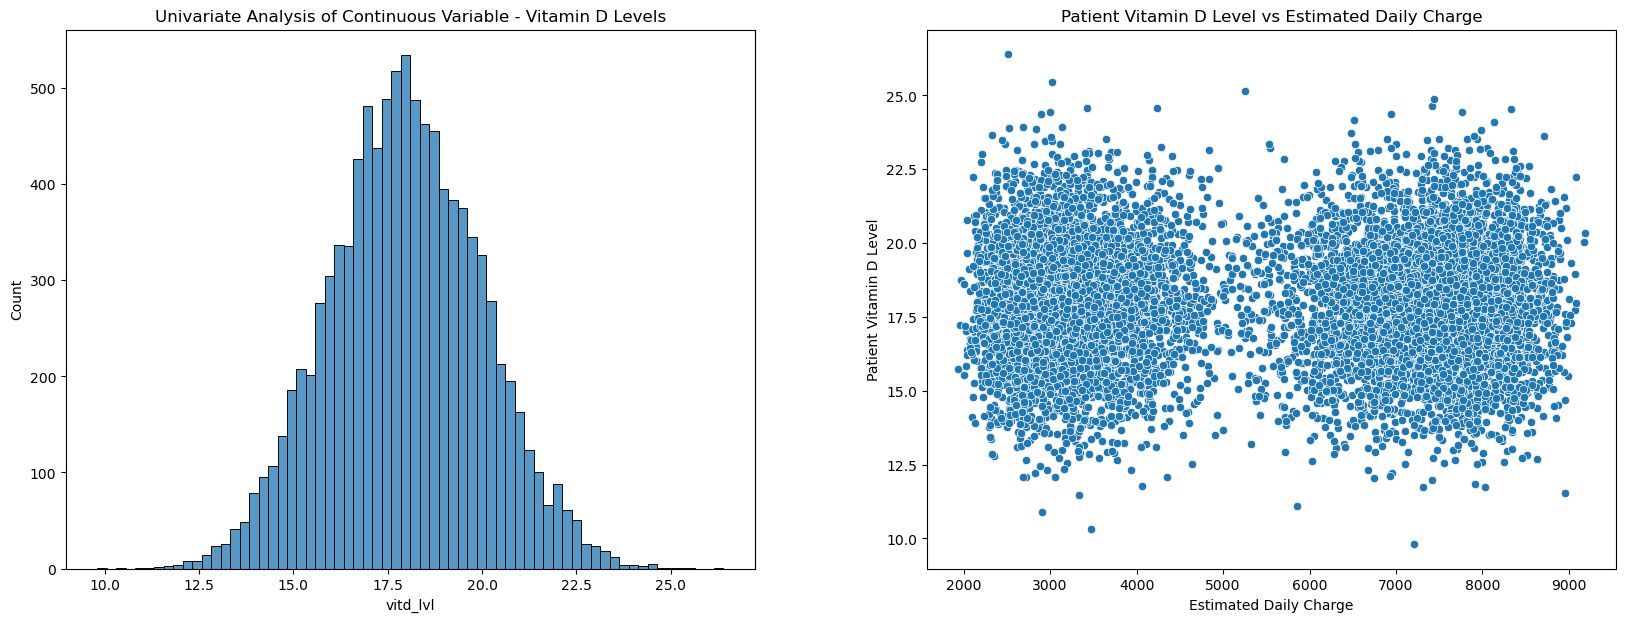

In [26]:
#Code conducting univariate and bivariate analysis exploring the vitamin D level variable and potential relationship with estimated daily charge
import seaborn as sns
import matplotlib.pyplot as plt
  
#Code for plotting univariate analysis of continuous variables in the form of histograms
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

sns.histplot(data=df, x="vitd_lvl", ax=ax[0])
ax[0].title.set_text("Univariate Analysis of Continuous Variable - Vitamin D Levels")

sns.scatterplot(data=df, x='est_daily_charge', y='vitd_lvl', ax=ax[1])
plt.xlabel("Estimated Daily Charge")
plt.ylabel("Patient Vitamin D Level")
ax[1].title.set_text('Patient Vitamin D Level vs Estimated Daily Charge')
plt.show()

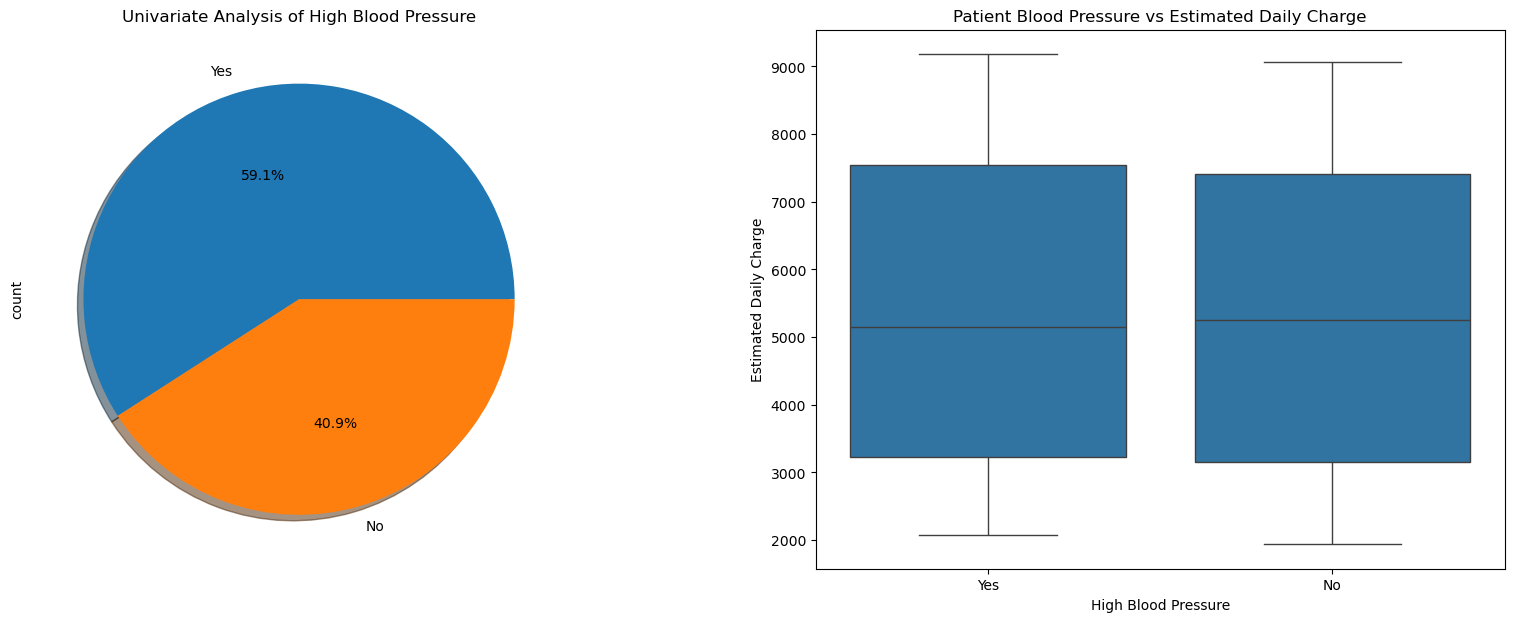

In [27]:
#Code for plotting univariate and bivariate analysis exploring the high blood pressure variable and potential relationship with estimated daily charge
import matplotlib.pyplot as plt
fig2, ax=plt.subplots(1,2)
fig2.subplots_adjust(hspace=0.125, wspace=0.25)
fig2.set_size_inches(20,7)

counts = df['high_blood_pressure'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of High Blood Pressure')

sns.boxplot(data=df, x='high_blood_pressure', y='est_daily_charge', ax=ax[1])
plt.xlabel("High Blood Pressure")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Blood Pressure vs Estimated Daily Charge')
plt.show()

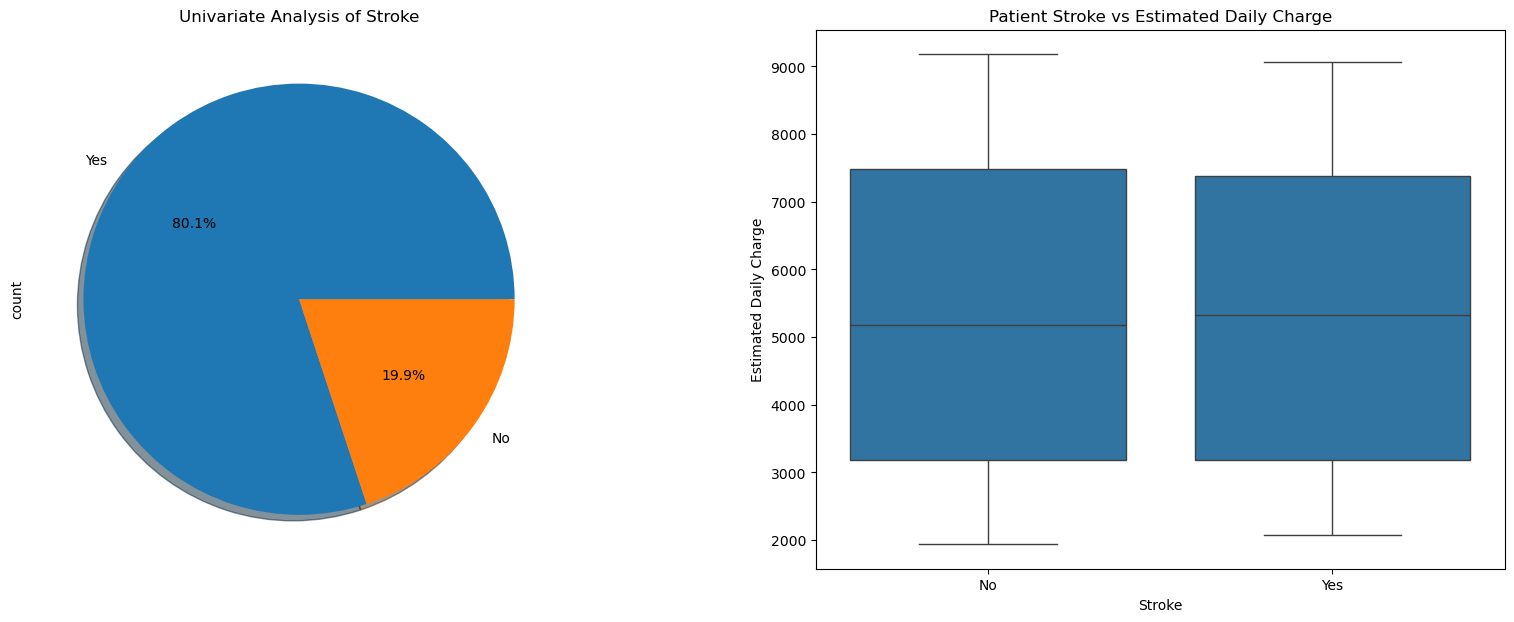

In [28]:
#Code for plotting univariate and bivariate analysis exploring the stroke variable and potential relationship with estimated daily charge
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['stroke'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Stroke')

sns.boxplot(data=df, x='stroke', y='est_daily_charge', ax=ax[1])
plt.xlabel("Stroke")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Stroke vs Estimated Daily Charge')
plt.show()

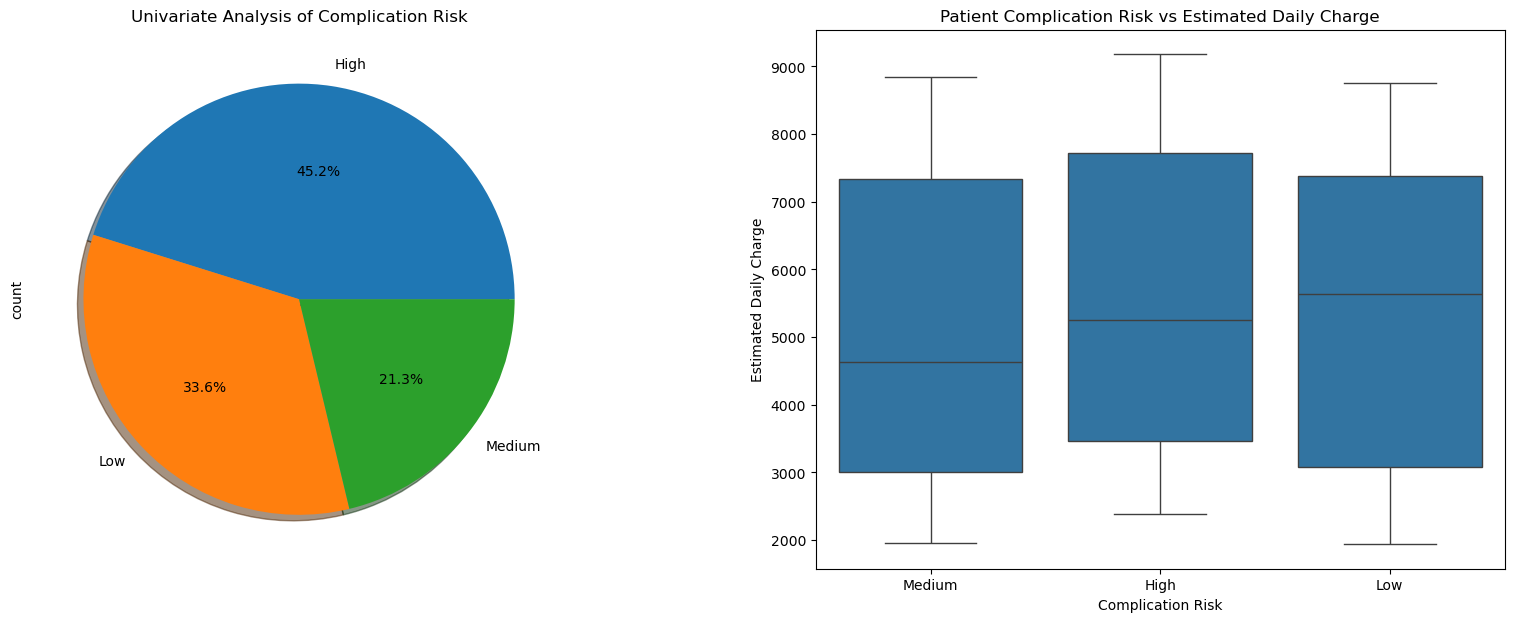

In [29]:
#Code for plotting univariate and bivariate analysis exploring the complication risk variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['complication_risk'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['High', 'Low', 'Medium'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Complication Risk')

sns.boxplot(data=df, x='complication_risk', y='est_daily_charge', ax=ax[1])
plt.xlabel("Complication Risk")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Complication Risk vs Estimated Daily Charge')
plt.show()

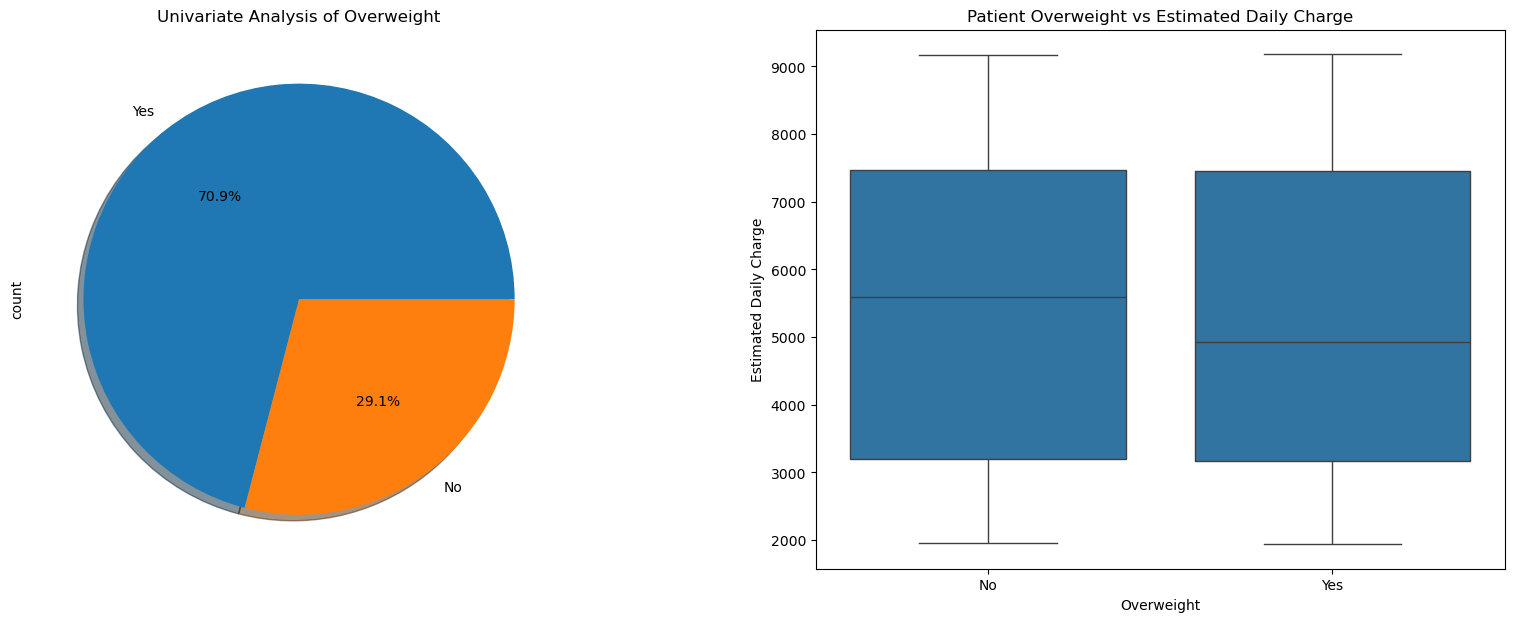

In [30]:
#Code for plotting univariate and bivariate analysis exploring the overweight variable and potential relationship with estimated daily charge
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['overweight'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Overweight')

sns.boxplot(data=df, x='overweight', y='est_daily_charge', ax=ax[1])
plt.xlabel("Overweight")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Overweight vs Estimated Daily Charge')
plt.show()

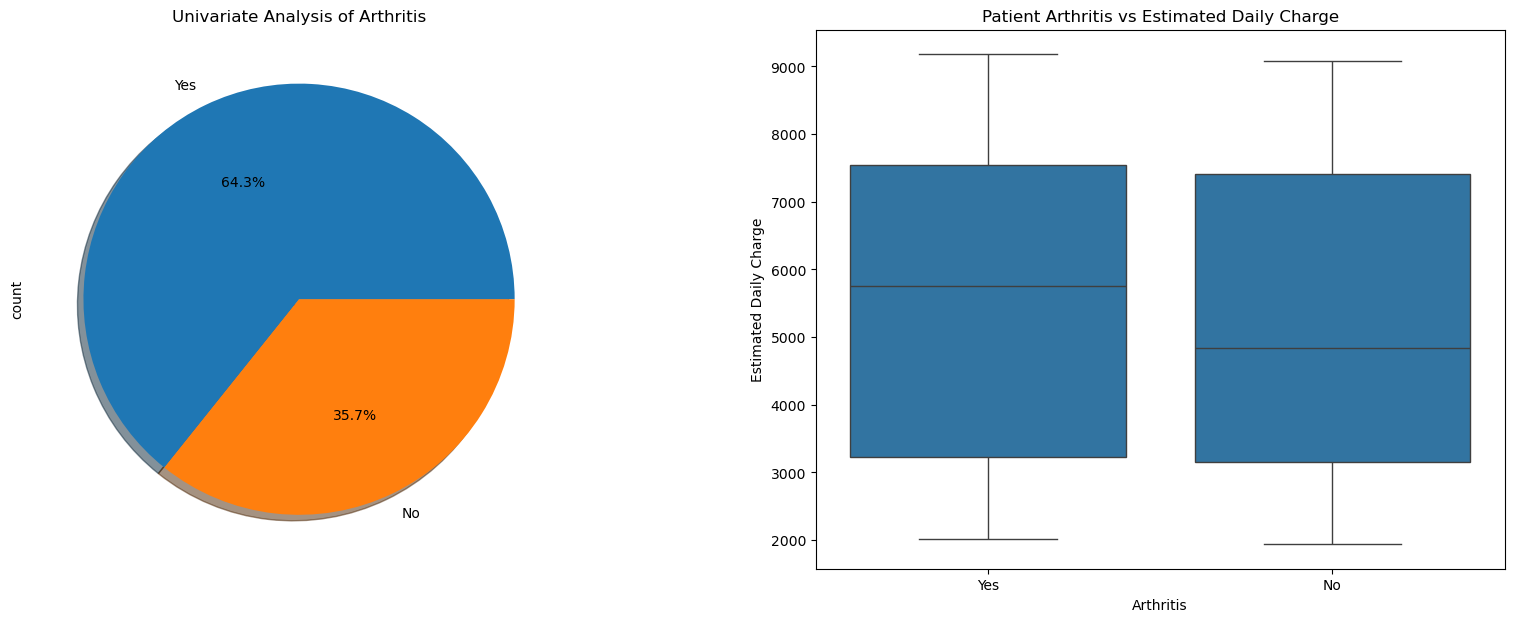

In [31]:
#Code for plotting univariate and bivariate analysis exploring the arthritis variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['arthritis'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Arthritis')

sns.boxplot(data=df, x='arthritis', y='est_daily_charge', ax=ax[1])
plt.xlabel('Arthritis')
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Arthritis vs Estimated Daily Charge')
plt.show()

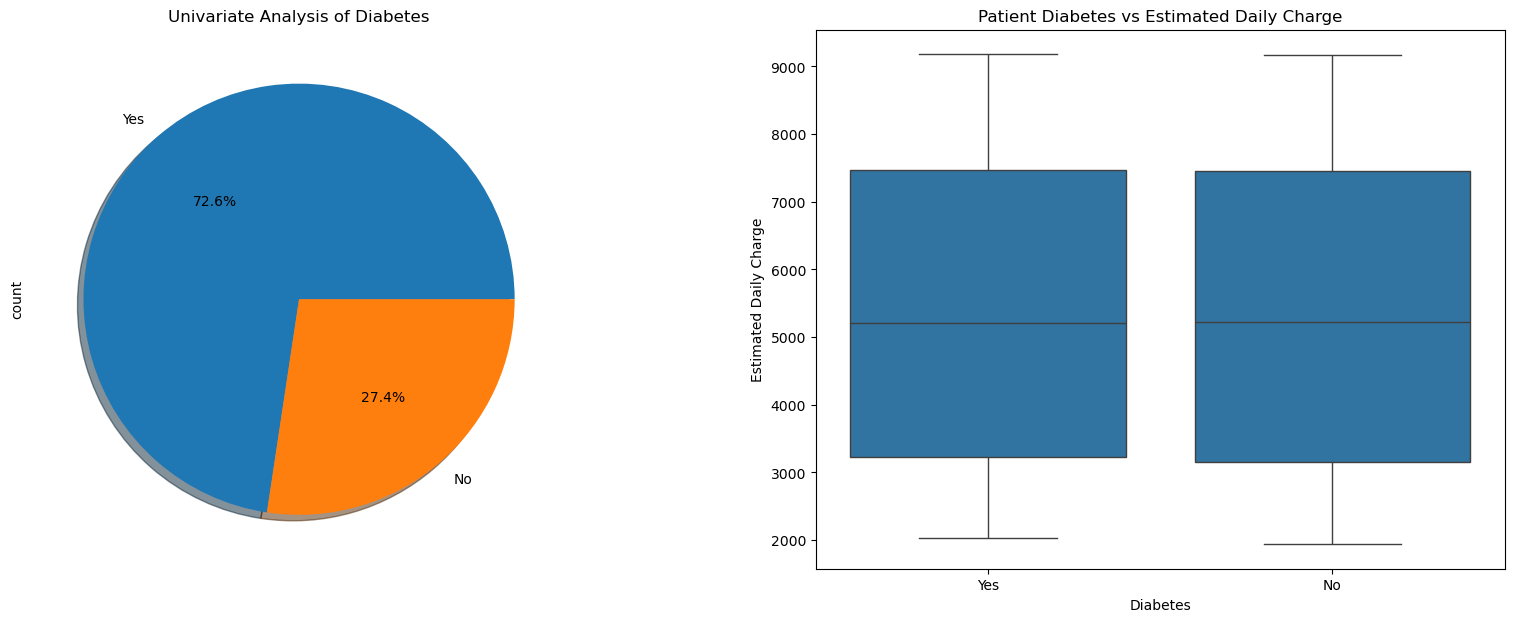

In [32]:
#Code for plotting univariate and bivariate analysis exploring the diabetes variable and potential relationship with estimated daily charge
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['diabetes'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Diabetes')

sns.boxplot(data=df, x='diabetes', y='est_daily_charge', ax=ax[1])
plt.xlabel("Diabetes")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Diabetes vs Estimated Daily Charge')
plt.show()

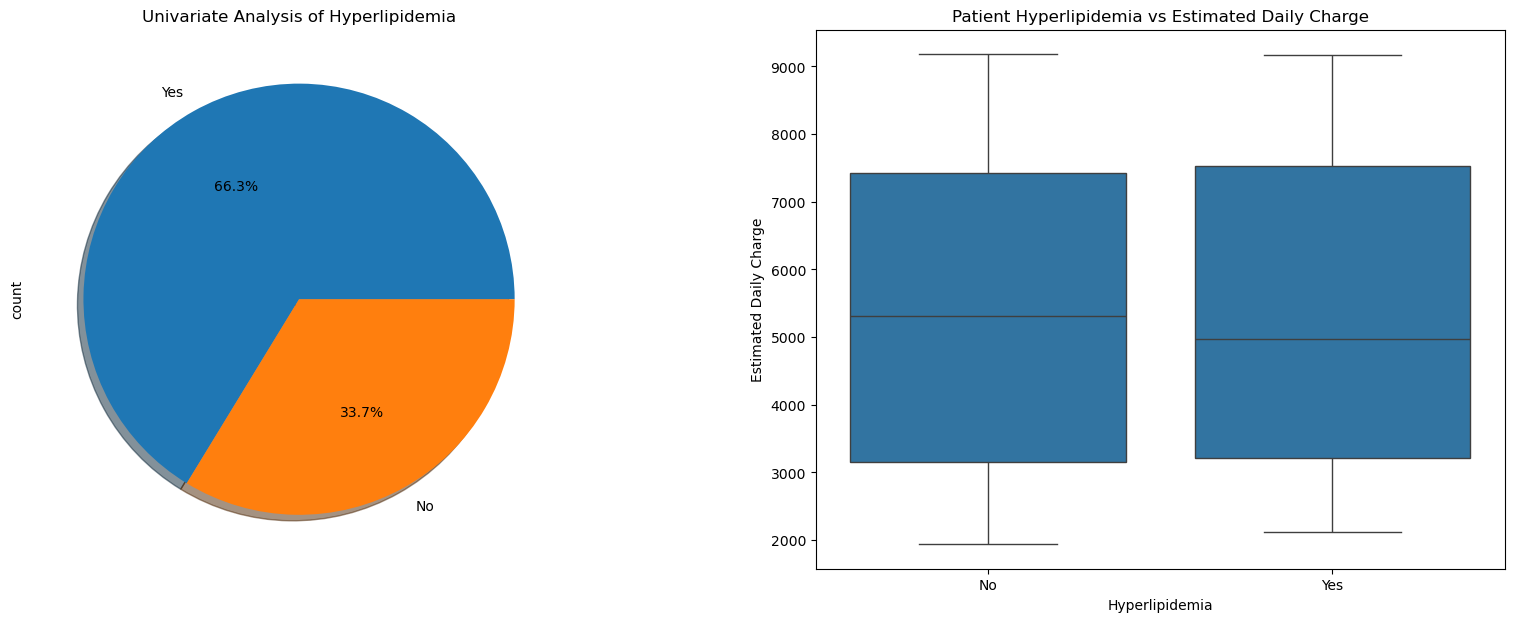

In [33]:
#Code for plotting univariate and bivariate analysis exploring the hyperlipidemia variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['hyperlipidemia'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Hyperlipidemia')

sns.boxplot(data=df, x='hyperlipidemia', y='est_daily_charge', ax=ax[1])
plt.xlabel("Hyperlipidemia")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Hyperlipidemia vs Estimated Daily Charge')
plt.show()

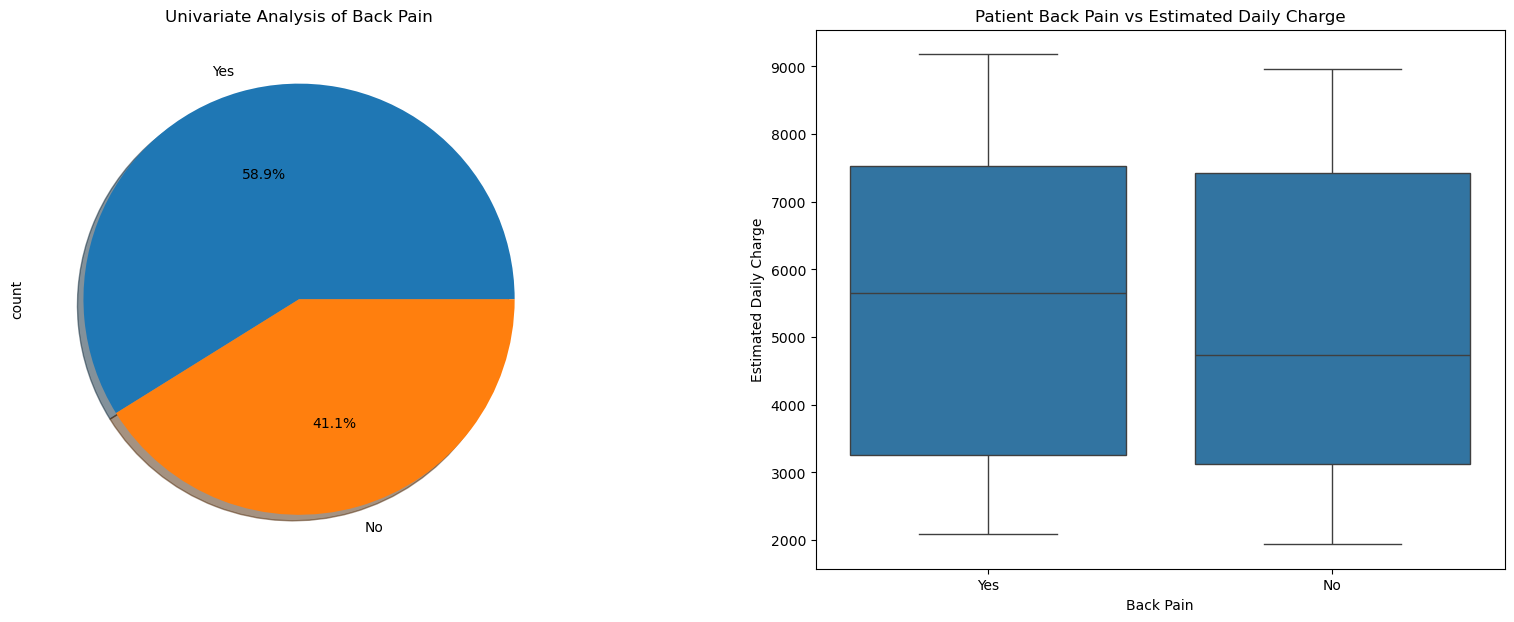

In [34]:
#Code for plotting univariate and bivariate analysis exploring the back pain variable and potential relationship with estimated daily charge
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['back_pain'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Back Pain')

sns.boxplot(data=df, x='back_pain', y='est_daily_charge', ax=ax[1])
plt.xlabel("Back Pain")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Back Pain vs Estimated Daily Charge')
plt.show()

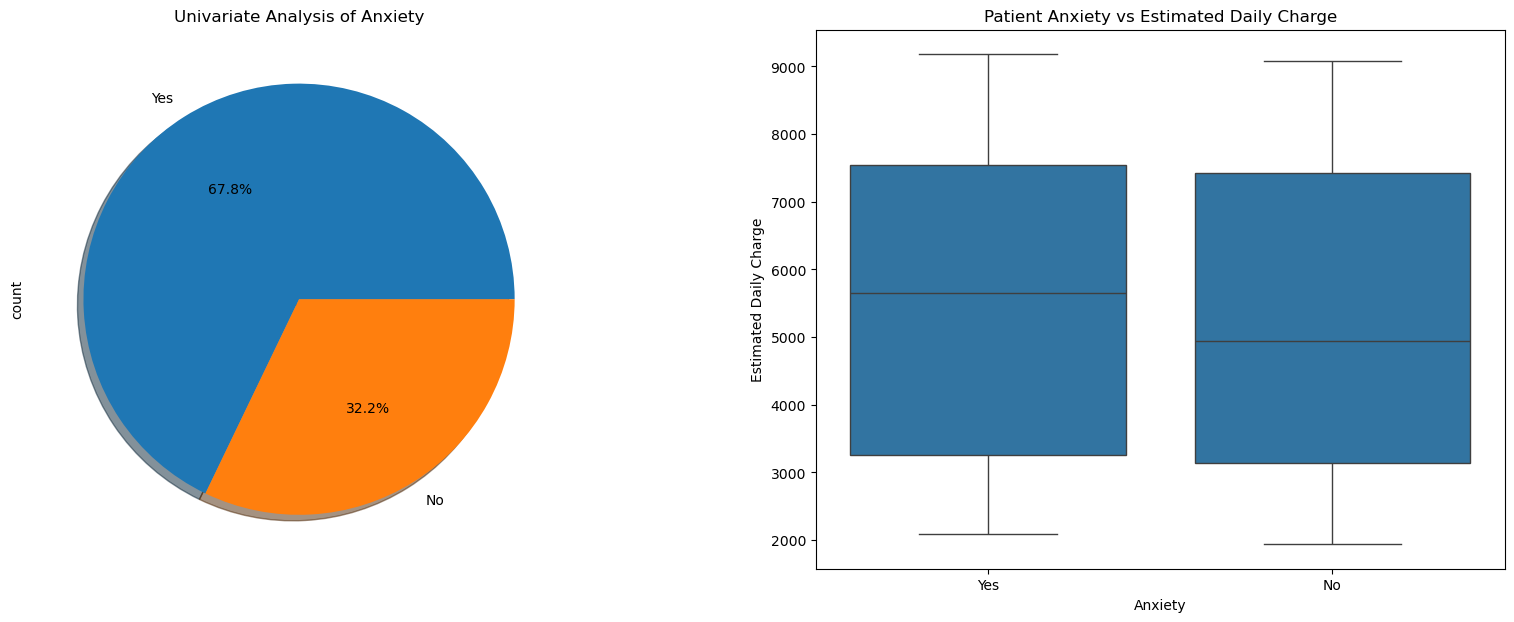

In [35]:
#Code for plotting univariate and bivariate analysis exploring the anxiety variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['anxiety'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Anxiety')

sns.boxplot(data=df, x='anxiety', y='est_daily_charge', ax=ax[1])
plt.xlabel("Anxiety")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Anxiety vs Estimated Daily Charge')
plt.show()

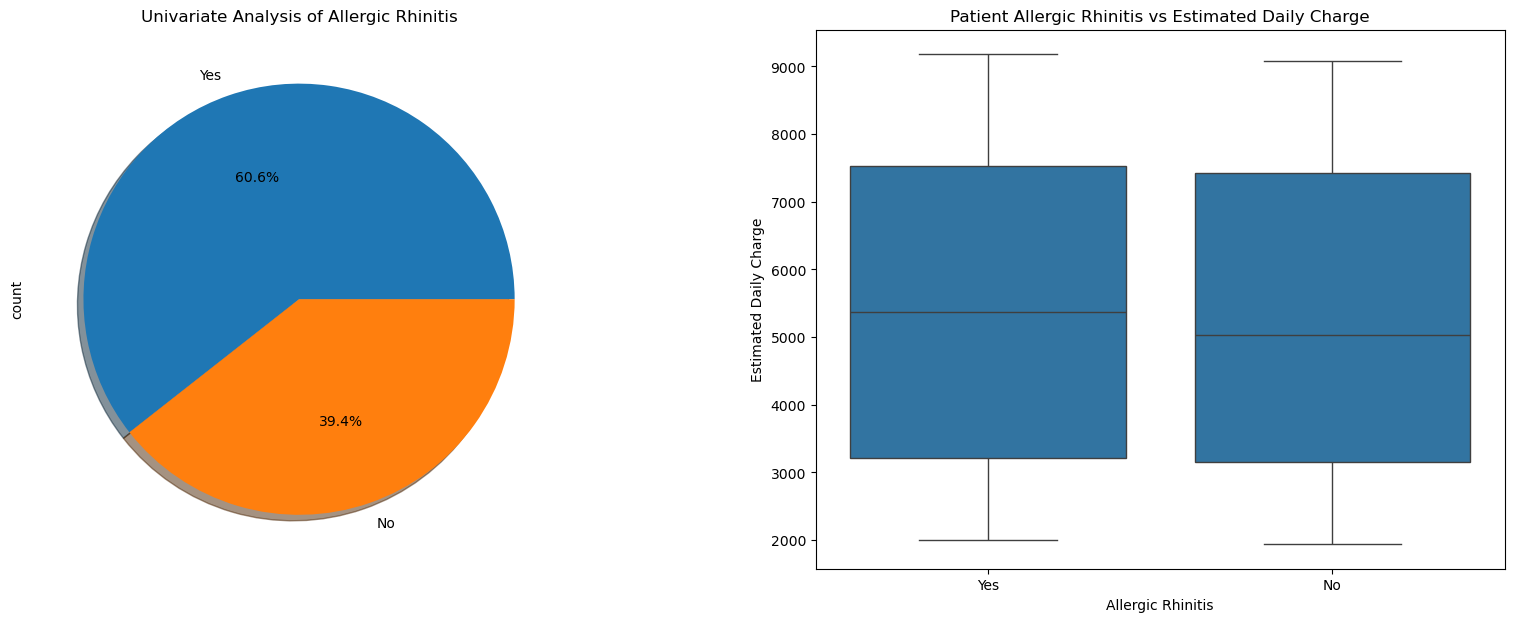

In [36]:
#Code for plotting univariate and bivariate analysis exploring the allergic rhinitis variable and potential relationship with estimated daily charge
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['allergic_rhinitis'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Allergic Rhinitis')

sns.boxplot(data=df, x='allergic_rhinitis', y='est_daily_charge', ax=ax[1])
plt.xlabel("Allergic Rhinitis")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Allergic Rhinitis vs Estimated Daily Charge')
plt.show()

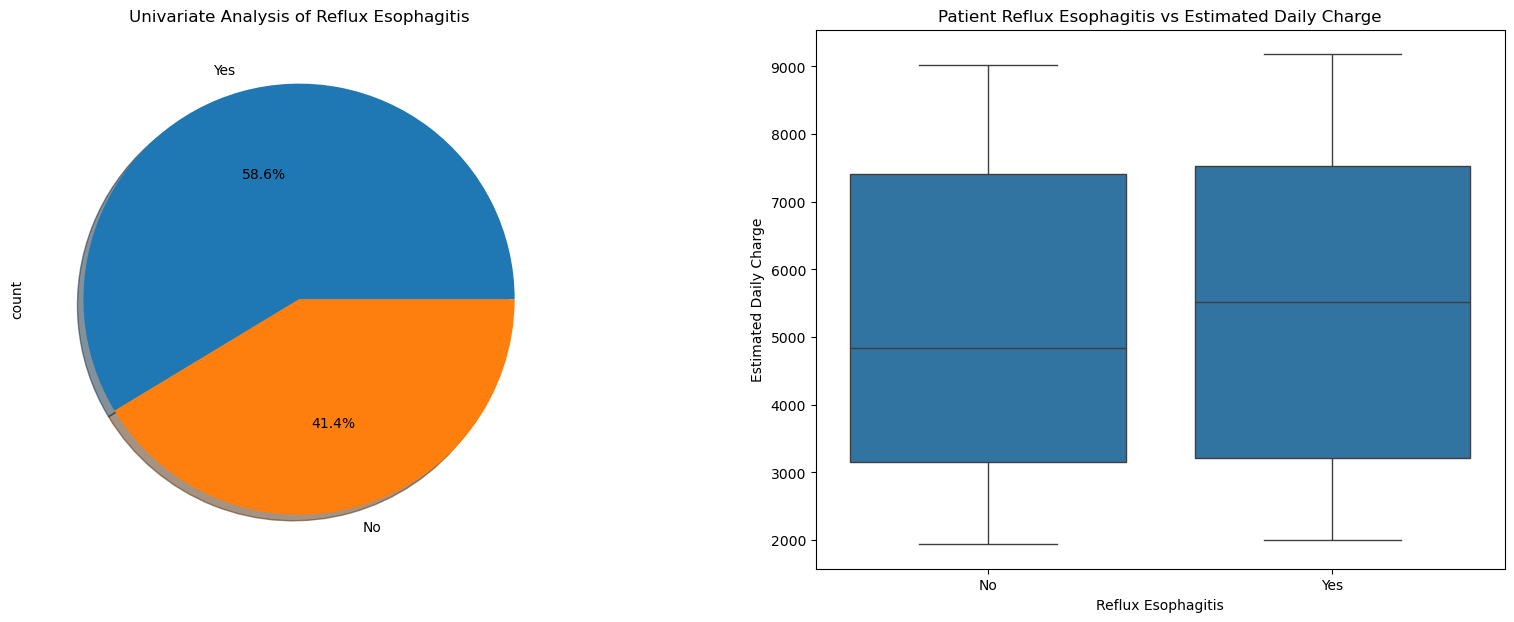

In [37]:
#Code for plotting univariate and bivariate analysis exploring the reflux esophagitis variable and potential relationship with patient readmission
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['reflux_esophagitis'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Reflux Esophagitis')

sns.boxplot(data=df, x='reflux_esophagitis', y='est_daily_charge', ax=ax[1])
plt.xlabel("Reflux Esophagitis")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Reflux Esophagitis vs Estimated Daily Charge')
plt.show()

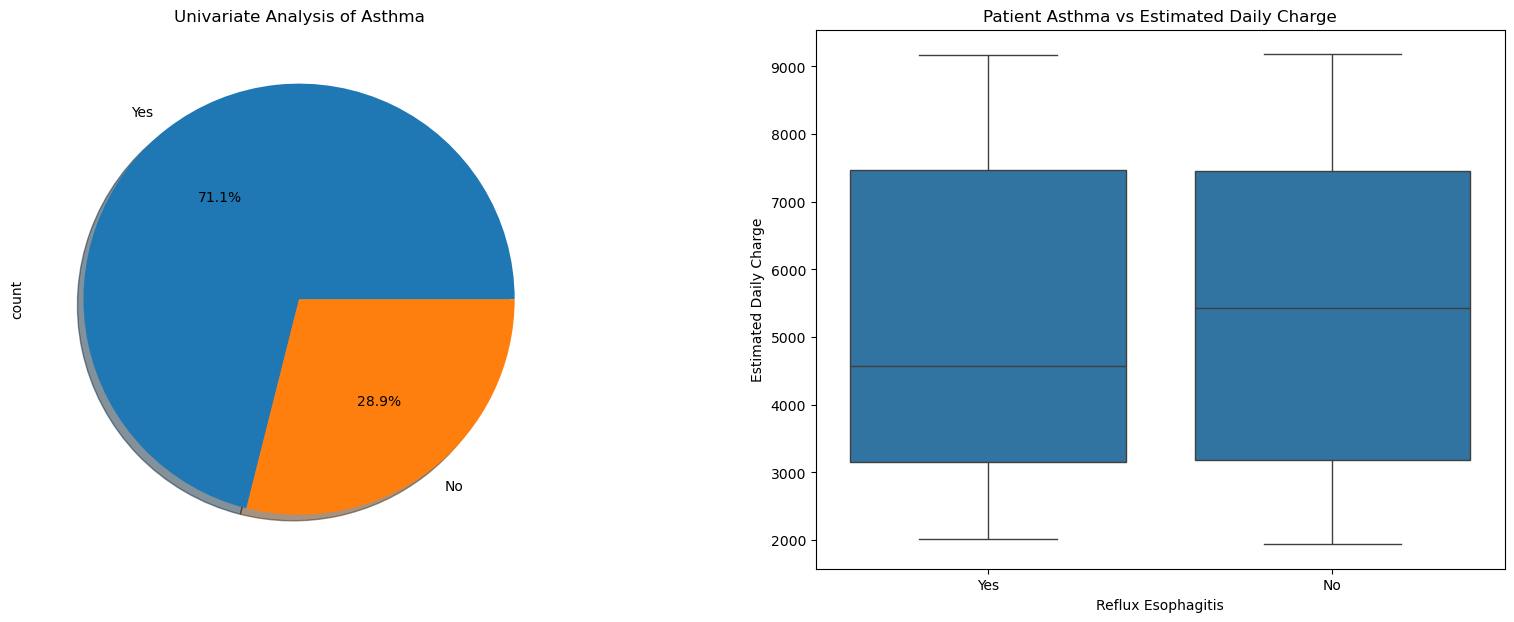

In [38]:
#Code for plotting univariate and bivariate analysis exploring the asthma variable and potential relationship with estimated daily charge
import matplotlib.pyplot as plt
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

counts = df['asthma'].value_counts(dropna=False)
counts.plot.pie(autopct='%1.1f%%', labels=['Yes', 'No'], shadow=True, ax=ax[0])
ax[0].title.set_text('Univariate Analysis of Asthma')

sns.boxplot(data=df, x='asthma', y='est_daily_charge', ax=ax[1])
plt.xlabel("Reflux Esophagitis")
plt.ylabel("Estimated Daily Charge")
ax[1].title.set_text('Patient Asthma vs Estimated Daily Charge')
plt.show()

In [39]:
#state
df["state"] = df["state"].astype("category")

#zip
df['zip'] = df['zip'].astype("str").str.zfill(5)

#area
df["area"] = df["area"].astype("category")

#timezone
df["timezone"] = df["timezone"].astype("category")

#children_in_household
df["children_in_household"] = df["children_in_household"].astype("Int64")

#marital_status
df["marital_status"] = df["marital_status"].astype("category")

#gender
df["gender"] = df["gender"].astype("category")

#initial_admin
df["initial_admin"] = df["initial_admin"].astype("category")

#complication_risk
df["complication_risk"] = df["complication_risk"].astype("category")

#services
df["services"] = df["services"].astype("category")

#likert_timely_admission
df["likert_timely_admission"] = df["likert_timely_admission"].astype("category")

#likert_timely_treatment
df["likert_timely_treatment"] = df["likert_timely_treatment"].astype("category")

#likert_timely_visit
df["likert_timely_visit"] = df["likert_timely_visit"].astype("category")

#likert_reliablity
df["likert_reliablity"] = df["likert_reliablity"].astype("category")

#likert_options
df["likert_options"] = df["likert_options"].astype("category")

#likert_treatment_hrs
df["likert_treatment_hrs"] = df["likert_treatment_hrs"].astype("category")

#likert_courteous_staff
df["likert_courteous_staff"] = df["likert_courteous_staff"].astype("category")

#likert_dr_active_listening
df["likert_dr_active_listening"] = df["likert_dr_active_listening"].astype("category")

#Code converting the "complication_risk" variable into two new binary variables using dummy coding
comp_risk = pd.get_dummies(data=df["complication_risk"], drop_first=True, dtype=int)
#One-hot encoding converting categorical variables into numerical format by generating a new binary column for each category
df['high_blood_pressure'] = df['high_blood_pressure'].map({'Yes': 1, 'No': 0})
df['stroke'] = df['stroke'].map({'Yes': 1, 'No': 0})
df['overweight'] = df['overweight'].map({'Yes': 1, 'No': 0})
df['arthritis'] = df['arthritis'].map({'Yes': 1, 'No': 0})
df['diabetes'] = df['diabetes'].map({'Yes': 1, 'No': 0})
df['hyperlipidemia'] = df['hyperlipidemia'].map({'Yes': 1, 'No': 0})
df['back_pain'] = df['back_pain'].map({'Yes': 1, 'No': 0})
df['anxiety'] = df['anxiety'].map({'Yes': 1, 'No': 0})
df['allergic_rhinitis'] = df['allergic_rhinitis'].map({'Yes': 1, 'No': 0})
df['reflux_esophagitis'] = df['reflux_esophagitis'].map({'Yes': 1, 'No': 0})
df['asthma'] = df['asthma'].map({'Yes': 1, 'No': 0})
#Code to reduce dataset to only include the variables we care about for the multiple regression model
linear_df = df[["vitd_lvl", "high_blood_pressure", "stroke", "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain", "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma", "est_daily_charge"]]
# Dummies for Complication Risk
linear_df.insert(4, "comp_risk_medium", comp_risk.Medium)
linear_df.insert(4, "comp_risk_low", comp_risk.Low)
linear_df

,vitd_lvl,high_blood_pressure,stroke,overweight,comp_risk_low,comp_risk_medium,arthritis,diabetes,hyperlipidemia,back_pain,anxiety,allergic_rhinitis,reflux_esophagitis,asthma,est_daily_charge
CaseOrder,,,,,,,,,,,,,,,
1,19.141466,1,0,0,0,1,1,1,0,1,1,1,0,1,3726.702860
2,18.940352,1,0,1,0,0,0,0,0,0,0,0,1,0,4193.190458
3,18.057507,1,0,1,0,1,0,1,0,0,0,0,0,0,2434.234222
4,16.576858,0,1,0,0,1,1,0,0,0,0,0,1,1,2127.830423
5,17.439069,0,0,0,1,0,0,0,1,0,0,1,0,0,2113.073274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,16.980860,1,0,0,0,1,0,0,0,0,1,0,1,0,6850.942000
9997,18.177020,1,0,1,0,1,1,1,0,0,0,0,0,1,7741.690000
9998,17.129070,1,0,1,0,0,0,0,0,0,1,1,0,0,8276.481000


In [40]:
# Save dataset to CSV, ignore index (if included, this will create an additional unnecessary column)
linear_df.to_csv('mrm.csv', index=False)
linear_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   vitd_lvl             10000 non-null  float64
 1   high_blood_pressure  10000 non-null  int64  
 2   stroke               10000 non-null  int64  
 3   overweight           10000 non-null  int64  
 4   comp_risk_low        10000 non-null  int32  
 5   comp_risk_medium     10000 non-null  int32  
 6   arthritis            10000 non-null  int64  
 7   diabetes             10000 non-null  int64  
 8   hyperlipidemia       10000 non-null  int64  
 9   back_pain            10000 non-null  int64  
 10  anxiety              10000 non-null  int64  
 11  allergic_rhinitis    10000 non-null  int64  
 12  reflux_esophagitis   10000 non-null  int64  
 13  asthma               10000 non-null  int64  
 14  est_daily_charge     10000 non-null  float64
dtypes: float64(2), int32(2), int64(11)
memory

In [41]:
import statsmodels.api as sm
y = linear_df.est_daily_charge
X = linear_df[["vitd_lvl","high_blood_pressure", "stroke", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     9.446
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           3.51e-21
Time:                        09:33:42   Log-Likelihood:                -90996.
No. Observations:               10000   AIC:                         1.820e+05
Df Residuals:                    9985   BIC:                         1.821e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
vitd_lvl                0.1987    

In [42]:
model.resid.std(ddof=X.shape[1])

2167.6152062929646

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x = linear_df[["vitd_lvl", "high_blood_pressure", "stroke", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)
vif_df = pd.DataFrame()
vif_df["feature"] = X.columns

vif_df["VIF"] = [variance_inflation_factor(x.values, i)
for i in range(len(x.columns))]

print(vif_df)

                feature        VIF
0              vitd_lvl   1.001496
1   high_blood_pressure   1.001969
2                stroke   1.000942
3         comp_risk_low   1.287402
4      comp_risk_medium   1.287350
5            overweight   1.001813
6             arthritis   1.001871
7              diabetes   1.001636
8        hyperlipidemia   1.001136
9             back_pain   1.001716
10              anxiety   1.001106
11    allergic_rhinitis   1.000847
12   reflux_esophagitis   1.001080
13               asthma   1.001141
14                const  90.231187


In [44]:
from sklearn import preprocessing
regress_df = pd.DataFrame(preprocessing.MinMaxScaler().fit_transform(linear_df), columns=linear_df.columns)
regress_df

,vitd_lvl,high_blood_pressure,stroke,overweight,comp_risk_low,comp_risk_medium,arthritis,diabetes,hyperlipidemia,back_pain,anxiety,allergic_rhinitis,reflux_esophagitis,asthma,est_daily_charge
0,0.562756,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.246933
1,0.550632,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.311343
2,0.497410,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.068475
3,0.408150,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.026168
4,0.460128,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.024130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.432505,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.678314
9996,0.504615,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.801304
9997,0.441440,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.875146
9998,0.609113,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.787882


In [45]:
x = regress_df[["vitd_lvl", "high_blood_pressure", "stroke", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)
vif_df = pd.DataFrame()
vif_df["feature"] = x.columns

vif_df["VIF"] = [variance_inflation_factor(x.values, i)
for i in range(len(x.columns))]

print(vif_df)

                feature        VIF
0              vitd_lvl   1.001496
1   high_blood_pressure   1.001969
2                stroke   1.000942
3         comp_risk_low   1.287402
4      comp_risk_medium   1.287350
5            overweight   1.001813
6             arthritis   1.001871
7              diabetes   1.001636
8        hyperlipidemia   1.001136
9             back_pain   1.001716
10              anxiety   1.001106
11    allergic_rhinitis   1.000847
12   reflux_esophagitis   1.001080
13               asthma   1.001141
14                const  27.043194


In [46]:
#Remove vitd_lvl with a p-value of 0.991
y = regress_df.est_daily_charge
X = regress_df[["high_blood_pressure", "stroke", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     10.17
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           1.07e-21
Time:                        09:33:42   Log-Likelihood:                -2118.6
No. Observations:               10000   AIC:                             4265.
Df Residuals:                    9986   BIC:                             4366.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
high_blood_pressure     0.0119    

In [47]:
#Remove stroke with a p-value of 0.794
y = regress_df.est_daily_charge
X = regress_df[["high_blood_pressure", "comp_risk_low", "comp_risk_medium",
       "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     11.02
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           3.24e-22
Time:                        09:33:42   Log-Likelihood:                -2118.6
No. Observations:               10000   AIC:                             4263.
Df Residuals:                    9987   BIC:                             4357.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
high_blood_pressure     0.0119    

In [48]:
#Remove overweight with a p-value of 0.246
y = regress_df.est_daily_charge
X = regress_df[["high_blood_pressure", "comp_risk_low", "comp_risk_medium",
       "arthritis", "diabetes", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     11.90
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           1.70e-22
Time:                        09:33:42   Log-Likelihood:                -2119.3
No. Observations:               10000   AIC:                             4263.
Df Residuals:                    9988   BIC:                             4349.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
high_blood_pressure     0.0117    

In [49]:
#Remove diabetes with a p-value of 0.217
y = regress_df.est_daily_charge
X = regress_df[["high_blood_pressure", "comp_risk_low", "comp_risk_medium",
       "arthritis", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis", "asthma"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     12.93
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           9.29e-23
Time:                        09:33:42   Log-Likelihood:                -2120.1
No. Observations:               10000   AIC:                             4262.
Df Residuals:                    9989   BIC:                             4341.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
high_blood_pressure     0.0117    

In [50]:
#Remove asthma with a p-value of 0.158
y = regress_df.est_daily_charge
X = regress_df[["high_blood_pressure", "comp_risk_low", "comp_risk_medium",
       "arthritis", "hyperlipidemia", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     14.15
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           6.08e-23
Time:                        09:33:42   Log-Likelihood:                -2121.1
No. Observations:               10000   AIC:                             4262.
Df Residuals:                    9990   BIC:                             4334.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
high_blood_pressure     0.0116    

In [51]:
#Remove allergic_rhinitis with a p-value of 0.078
y = regress_df.est_daily_charge
X = regress_df[["high_blood_pressure", "comp_risk_low", "comp_risk_medium",
       "arthritis", "hyperlipidemia", "back_pain",
       "anxiety", "reflux_esophagitis"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     15.52
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           6.46e-23
Time:                        09:33:42   Log-Likelihood:                -2122.6
No. Observations:               10000   AIC:                             4263.
Df Residuals:                    9991   BIC:                             4328.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
high_blood_pressure     0.0118    

In [52]:
#Remove high_blood_pressure with a p-value of 0.054
y = regress_df.est_daily_charge
X = regress_df[["comp_risk_low", "comp_risk_medium",
       "arthritis", "hyperlipidemia", "back_pain",
       "anxiety", "reflux_esophagitis"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     17.20
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           8.77e-23
Time:                        09:33:42   Log-Likelihood:                -2124.5
No. Observations:               10000   AIC:                             4265.
Df Residuals:                    9992   BIC:                             4323.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
comp_risk_low         -0.0441      0

In [53]:
#Remove hyperlipidemia with a p-value of 0.057
y = regress_df.est_daily_charge
X = regress_df[["comp_risk_low", "comp_risk_medium",
       "arthritis", "back_pain",
       "anxiety", "reflux_esophagitis"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     19.46
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           1.07e-22
Time:                        09:33:42   Log-Likelihood:                -2126.3
No. Observations:               10000   AIC:                             4267.
Df Residuals:                    9993   BIC:                             4317.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
comp_risk_low         -0.0441      0

In [54]:
#Check to see if adding #allergic_rhinitis back improves R-squared and adjusted R-squared
y = regress_df.est_daily_charge
X = regress_df[["comp_risk_low", "comp_risk_medium",
       "arthritis", "back_pain",
       "anxiety", "allergic_rhinitis", "reflux_esophagitis"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     17.13
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           1.11e-22
Time:                        09:33:42   Log-Likelihood:                -2124.7
No. Observations:               10000   AIC:                             4265.
Df Residuals:                    9992   BIC:                             4323.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
comp_risk_low         -0.0442      0

In [55]:
#Final reduced model
y = regress_df.est_daily_charge
X = regress_df[["comp_risk_low", "comp_risk_medium",
       "arthritis", "back_pain",
       "anxiety", "reflux_esophagitis"]].assign(const=1)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       est_daily_charge   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     19.46
Date:                Thu, 20 Mar 2025   Prob (F-statistic):           1.07e-22
Time:                        09:33:42   Log-Likelihood:                -2126.3
No. Observations:               10000   AIC:                             4267.
Df Residuals:                    9993   BIC:                             4317.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
comp_risk_low         -0.0441      0

In [56]:
results.resid.std(ddof=X.shape[1])

0.29940529728524706

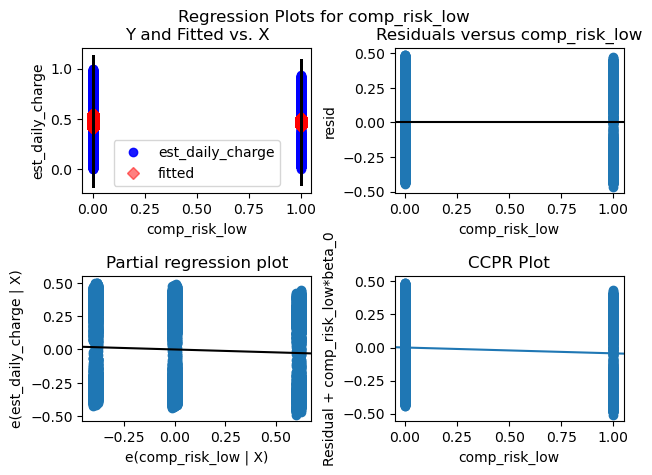

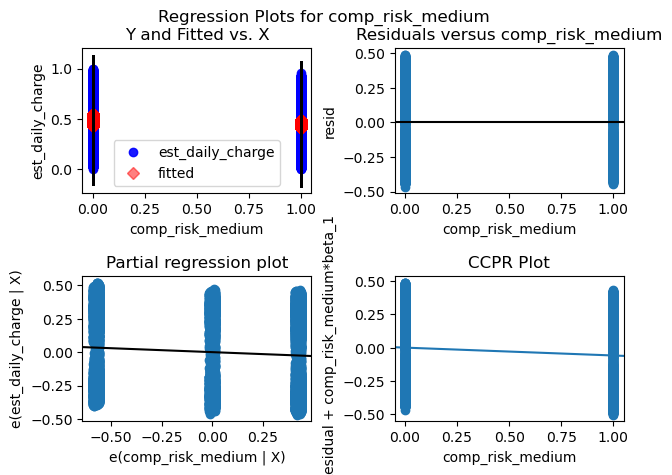

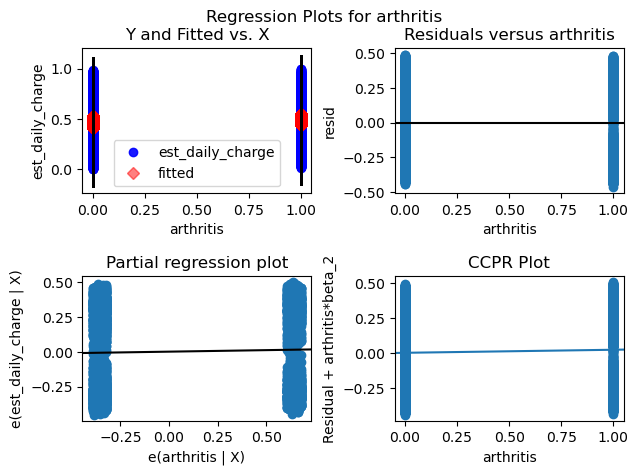

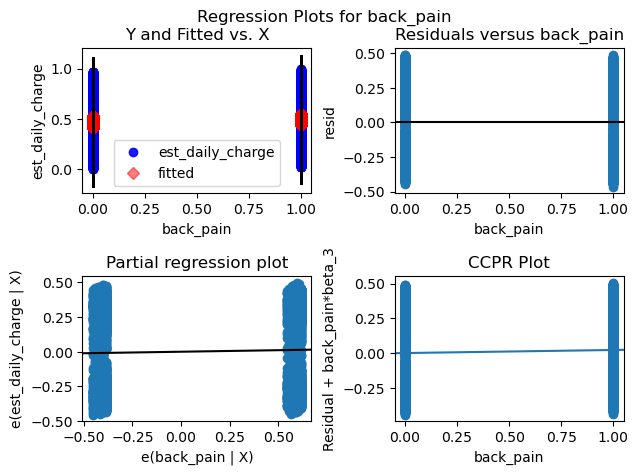

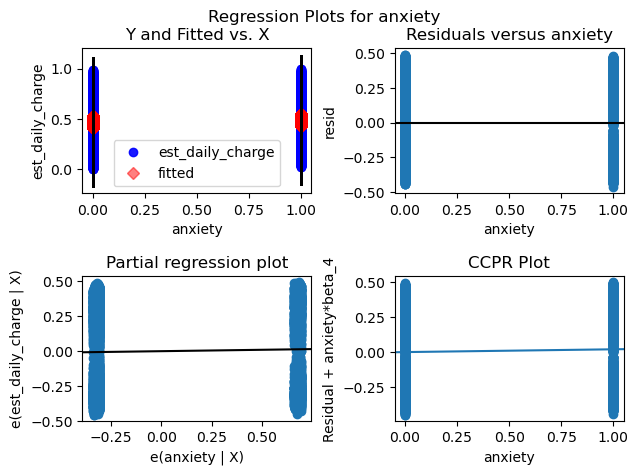

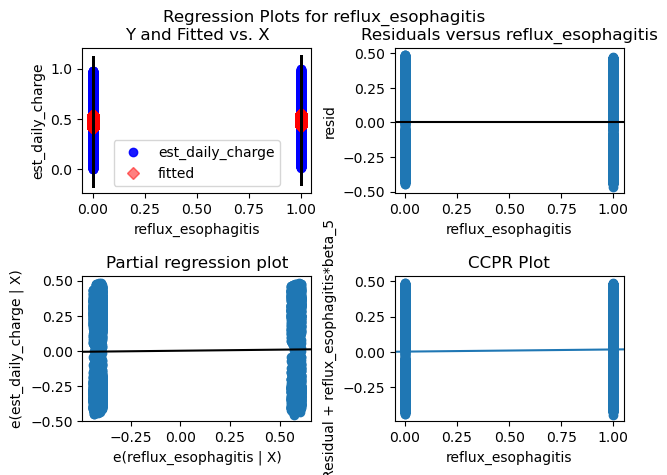

In [57]:
y = regress_df.est_daily_charge
X = regress_df[["comp_risk_low", "comp_risk_medium",
       "arthritis", "back_pain",
       "anxiety", "reflux_esophagitis"]].assign(const=1)

model = sm.OLS(y, X).fit()
fig = sm.graphics.plot_regress_exog(model, exog_idx=0)
model = sm.OLS(y, X).fit()
fig = sm.graphics.plot_regress_exog(model, exog_idx=1)
model = sm.OLS(y, X).fit()
fig = sm.graphics.plot_regress_exog(model, exog_idx=2)
model = sm.OLS(y, X).fit()
fig = sm.graphics.plot_regress_exog(model, exog_idx=3)
model = sm.OLS(y, X).fit()
fig = sm.graphics.plot_regress_exog(model, exog_idx=4)
model = sm.OLS(y, X).fit()
fig = sm.graphics.plot_regress_exog(model, exog_idx=5)

In [58]:
#Code to convert coefficients back to original scale for better interpretability
print("low complication risk:","",-0.0441 * (linear_df.est_daily_charge.max()-linear_df.est_daily_charge.min()))
print("medium complication risk:","", -0.0589 * (linear_df.est_daily_charge.max()-linear_df.est_daily_charge.min()))
print("arthritis:","", 0.0218 * (linear_df.est_daily_charge.max()-linear_df.est_daily_charge.min()))
print("back_pain:","", 0.0220 * (linear_df.est_daily_charge.max()-linear_df.est_daily_charge.min()))
print("anxiety:","", 0.0200 * (linear_df.est_daily_charge.max()-linear_df.est_daily_charge.min()))
print("reflux_esophagitis:","", 0.0152 * (linear_df.est_daily_charge.max()-linear_df.est_daily_charge.min()))

low complication risk:  -319.39054264529994
medium complication risk:  -426.5782984537
arthritis:  157.88466733939998
back_pain:  159.33315052599997
anxiety:  144.84831866
reflux_esophagitis:  110.08472218159999
